# ECS647U/773P - Bayesian Decision and Risk Analysis
## Coursework: Bayesian Network & Influence Diagram - Radiotherapy Treatment Planning

**Full Name:** [Your Name]  
**Student Number:** [Your Number]

---

### Domain
This notebook models **radiotherapy treatment plan quality** - specifically, factors that determine whether a treatment plan will pass quality assurance (QA) before delivery to a patient. The model is constructed entirely from **expert elicitation** (a medical physicist with direct clinical experience in radiotherapy), supplemented by literature. No dataset is used.

### BN Node Summary (6 chance nodes)

| Node | Type | States |
|---|---|---|
| `TumourComplexity` | Root | Normal / Complex |
| `OARProximity` | Root | Low / Medium / High |
| `PlanOptimisationQuality` | Intermediate | target_prioritised / balanced / oar_prioritised |
| `DoseCoverage` | Intermediate | Inadequate / Adequate / Optimal |
| `OARDose` | Intermediate | Low / Medium / High |
| `PlanQAOutcome` | Leaf | Pass / Minor_flag / Fail |


---
## Cell 1 - Imports
**Purpose:** Import all required libraries. Only pyAgrum is used for probabilistic modelling, as required by the coursework specification. Supports Q2–Q8.

In [ ]:
!pip install pyagrum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.causal as csl

import matplotlib.pyplot as plt
import numpy as np

print(f"pyAgrum version: {gum.__version__}")
print("All imports successful.")

pyAgrum version: 2.3.2
All imports successful.


## Q2 - Network Structure

BN has  6 nodes
and  6  arcs


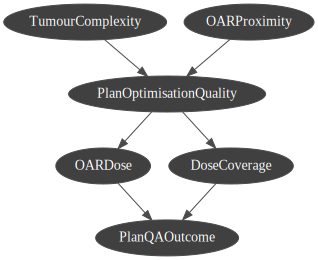

In [ ]:
bn = gum.BayesNet("RadiotherapyPlanQuality")

# Root Nodes

TC = bn.add(gum.LabelizedVariable("TumourComplexity",
                                  "Complexity of the tumour geometry",
                                   ["Normal", "Complex"]))

OARP = bn.add(gum.LabelizedVariable("OARProximity",
                                    "Organs at risk Proximity to target",
                                     ["Low", "Medium", "High"]))


# Intermediate Nodes

POQ = bn.add(gum.LabelizedVariable("PlanOptimisationQuality",
                                   "Trade-off decision made during plan optimisation",
                                    ["target_prioritised", "balanced", "oar_prioritised"]))

DC = bn.add(gum.LabelizedVariable("DoseCoverage",
                                  "Amount of prescribed dose received by the target",
                                   ["Inadequate", "Adequate", "Optimal"]))

OARD = bn.add(gum.LabelizedVariable("OARDose",
                                    "Amount of dose received by organs at risk",
                                     ["Low", "Medium", "High"]))


# Leaf Node

PQO = bn.add(gum.LabelizedVariable("PlanQAOutcome",
                                   "Outcome of the plan quality assurance check",
                                    ["Pass", "Minor_flag", "Fail"]))

bn.addArc(TC, POQ)
bn.addArc(OARP, POQ)
bn.addArc(POQ, DC)
bn.addArc(POQ, OARD)
bn.addArc(DC, PQO)
bn.addArc(OARD, PQO)

print("BN has ", bn.size(), "nodes")
print("and ", bn.sizeArcs(), " arcs")

gnb.showBN(bn)

The BN structure shown above was constructed entirely from expert knowledge, specifically through elicitation from a medical physicist with direct clinical experience in radiotherapy planning. No dataset was used. This approach was chosen because high-quality radiotherapy planning data is not publicly available in a form suitable for structure learning, and the causal relationships between planning variables are well understood clinically.

* The network contains 6 nodes and 6 arcs.
* TumourComplexity and OARProximity are root nodes, reflecting that tumour geometry and organ-at-risk positioning are independent patient characteristics that cannot be controlled at the planning stage.
* Both influence PlanOptimisationQuality, which captures how well the planning system can navigate these constraints.
* PlanOptimisationQuality then drives both DoseCoverage (how much prescribed dose reaches the target) and OARDose (how much dose falls on healthy tissue).
* Both of these feed into PlanQAOutcome, the leaf node representing whether the plan passes quality assurance.


ImagingQuality was removed from the initial design following further reflection with the medical physicist, who indicated that imaging quality influences planning indirectly and is already captured through its effect on optimisation quality.

# CPTs
Expert Elicited CPT's

In [ ]:
# Expert elicited: majority of plans are normal complexity (70% normal, 30% complex)
# for example a normal tumor vs a tumor at the heart or brain
bn.cpt("TumourComplexity").fillWith([0.70, 0.30])

# Expert elicited: most cases have moderate-high OAR proximity given radiotherapy targets
# often sit near critical structures. Low proximity is least common.
bn.cpt("OARProximity").fillWith([0.20, 0.50, 0.30])

gnb.sideBySide(bn.cpt("TumourComplexity"), bn.cpt("OARProximity"))


In [ ]:
bn.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "Low"}] = [0.05, 0.90, 0.05]
bn.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "Medium"}] = [0.20, 0.60, 0.20]
bn.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "High"}] = [0.35, 0.35, 0.30]
bn.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "Low"}] = [0.30, 0.50, 0.20]
bn.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "Medium"}] = [0.40, 0.30, 0.30]
bn.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "High"}] = [0.45, 0.15, 0.40]

gnb.sideBySide(bn.cpt("PlanOptimisationQuality"), captions=["P(PlanOptimisationQuality | TumourComplexity, OARProximity)"])

In [ ]:
# Expert elicited: DoseCoverage is driven by PlanOptimisationQuality.
# Good optimisation strongly predicts optimal coverage. Poor optimisation
# frequently results in inadequate target coverage.
bn.cpt("DoseCoverage")[{"PlanOptimisationQuality": "target_prioritised"}] = [0.05, 0.25, 0.70]
bn.cpt("DoseCoverage")[{"PlanOptimisationQuality": "balanced"}] = [0.10, 0.55, 0.35]
bn.cpt("DoseCoverage")[{"PlanOptimisationQuality": "oar_prioritised"}] = [0.60, 0.35, 0.05]

gnb.sideBySide(bn.cpt("DoseCoverage"), captions=["P(DoseCoverage | PlanOptimisationQuality)"])

In [ ]:
# Expert elicited: OARDose is driven by PlanOptimisationQuality.
# Good optimisation keeps OAR dose low. Poor optimisation leads to higher OAR dose.
# Expert confirmed overall QA fail rate ~2%, pass rate ~70%, minor flag ~28%.
bn.cpt("OARDose")[{"PlanOptimisationQuality": "target_prioritised"}] = [0.10, 0.30, 0.60]
bn.cpt("OARDose")[{"PlanOptimisationQuality": "balanced"}] = [0.30, 0.50, 0.20]
bn.cpt("OARDose")[{"PlanOptimisationQuality": "oar_prioritised"}] = [0.65, 0.30, 0.05]

gnb.sideBySide(bn.cpt("OARDose"), captions=["P(OARDose | PlanOptimisationQuality)"])

In [ ]:
# Expert elicited: PlanQAOutcome depends on DoseCoverage and OARDose.
# Optimal coverage + low OAR dose almost always passes. Inadequate coverage
# or high OAR dose drives minor flags and failures. Overall fail rate ~2%.
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Inadequate", "OARDose": "Low"}] = [0.60, 0.36, 0.04]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Inadequate", "OARDose": "Medium"}] = [0.40, 0.50, 0.10]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Inadequate", "OARDose": "High"}] = [0.20, 0.50, 0.30]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Adequate", "OARDose": "Low"}] = [0.85, 0.13, 0.02]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Adequate", "OARDose": "Medium"}] = [0.70, 0.27, 0.03]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Adequate", "OARDose": "High"}] = [0.50, 0.45, 0.05]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Optimal", "OARDose": "Low"}] = [0.97, 0.02, 0.01]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Optimal", "OARDose": "Medium"}] = [0.90, 0.08, 0.02]
bn.cpt("PlanQAOutcome")[{"DoseCoverage": "Optimal", "OARDose": "High"}] = [0.75, 0.22, 0.03]

gnb.sideBySide(bn.cpt("PlanQAOutcome"), captions=["P(PlanQAOutcome | DoseCoverage, OARDose)"])



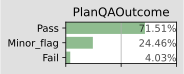

In [ ]:
# Verify marginal PlanQAOutcome matches contact's data
# Expected: ~70% pass, ~28% minor_flag, ~2% fail
gnb.showPosterior(bn, {}, "PlanQAOutcome")

# Question 4 - Reasoning

In [ ]:
# Q4.1 - Observational Reasoning (Rung 1 of the Ladder of Causation)
# Scenario: A complex tumour with high OAR proximity is observed.
# We compare the prior P(PlanQAOutcome) with the posterior given this evidence.
ie_prior = gum.LazyPropagation(bn)
ie_prior.makeInference()
ie_post = gum.LazyPropagation(bn)
ie_post.setEvidence({'TumourComplexity': 'Complex', 'OARProximity': 'High'})
ie_post.makeInference()
gnb.sideBySide(
    ie_prior.posterior('PlanQAOutcome'),
    ie_post.posterior('PlanQAOutcome'),
    captions=[
        "Prior: P(PlanQAOutcome) - no evidence",
        "Posterior: P(PlanQAOutcome | TumourComplexity = Complex, OARProximity = High)"
    ]
)

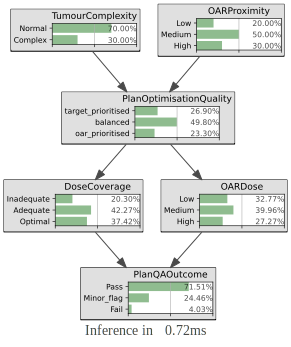

In [ ]:
# Full network views for Q4.1
gnb.showInference(bn, evs = {})

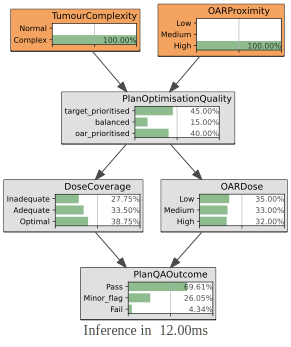

In [ ]:
gnb.showInference(bn, evs = {'TumourComplexity': 'Complex', 'OARProximity': 'High'})

In [ ]:
# Q4.2 - Interventional Reasoning (Rung 2 of the Ladder of Causation)
# Scenario: We compare observing PlanOptimisationQuality=target_prioritised
# vs actively intervening do(PlanOptimisationQuality=target_prioritised).
# Cuts incoming arcs from TumourComplexity and OARProximity to POQ.
cm = csl.CausalModel(bn)
ie_obs = gum.LazyPropagation(bn)
ie_obs.setEvidence({'PlanOptimisationQuality': 'target_prioritised'})
ie_obs.makeInference()
gnb.sideBySide(
    ie_obs.posterior('DoseCoverage'),
    ie_obs.posterior('OARDose'),
    ie_obs.posterior('PlanQAOutcome'),
    captions = [
        "P(DoseCoverage | POQ = target prioritised) - observational",
        "P(OARDose | POQ = target prioritised) - observational",
        "P(PlanQAOutcome | POQ = target prioritised) - observational"
    ]
)

In [ ]:
gnb.sideBySide(
    csl.causalImpact(cm, on='DoseCoverage', doing='PlanOptimisationQuality', values = {'PlanOptimisationQuality': 'target_prioritised'})[1],
    csl.causalImpact(cm, on='OARDose', doing='PlanOptimisationQuality', values = {'PlanOptimisationQuality': 'target_prioritised'})[1],
    csl.causalImpact(cm, on='PlanQAOutcome', doing='PlanOptimisationQuality', values = {'PlanOptimisationQuality': 'target_prioritised'})[1],
    captions=[
        "P(DoseCoverage | do(POQ = target prioritised)) - interventional",
        "P(OARDose | do(POQ = target prioritised)) - interventional",
        "P(PlanQAOutcome | do(POQ = target prioritised)) - interventional"
    ]
)

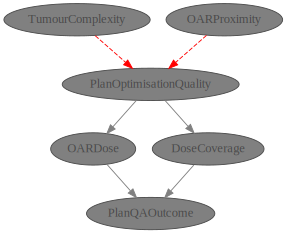

In [ ]:
# Q4.3 - Counterfactual Reasoning (Rung 3 of the Ladder of Causation)
# Observed world: plan failed QA, PlanOptimisationQuality was oar_prioritised.
# Counterfactual: would it still have failed if POQ had been balanced instead?
# Method: copy BN, erase arc into POQ from parents, fix counterfactual state.
bn_cf = gum.BayesNet(bn)
bn_cf.eraseArc('TumourComplexity', 'PlanOptimisationQuality')
bn_cf.eraseArc('OARProximity', 'PlanOptimisationQuality')
gnb.showBNDiff(bn, bn_cf, size="4")

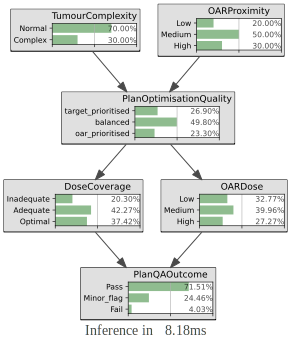

In [ ]:
# World 1: before observations
gnb.showInference(bn, evs={})

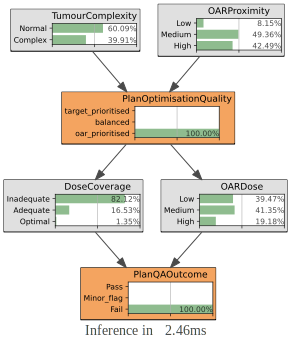

In [ ]:
# World 2: real world - plan failed, POQ was oar_prioritised
gnb.showInference(bn,
                  evs={'PlanQAOutcome': 'Fail',
                       'PlanOptimisationQuality': 'oar_prioritised'})

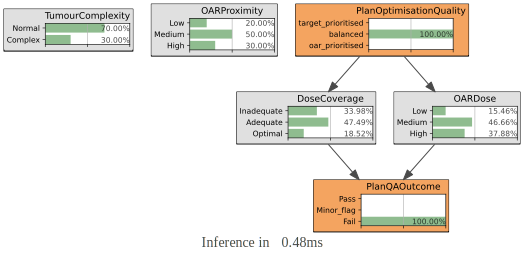

In [ ]:
# World 3: counterfactual - same failure but POQ = balanced
gnb.showInference(bn_cf,
                  evs={'PlanQAOutcome': 'Fail',
                       'PlanOptimisationQuality': 'balanced'})


# Q5 - Inference Diagram

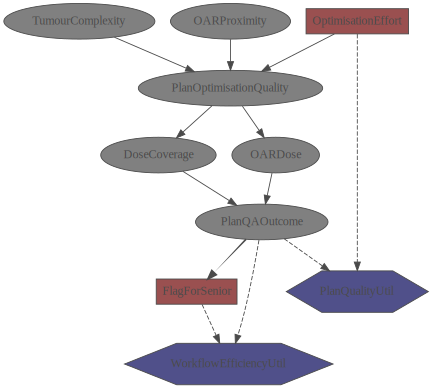

In [ ]:
# Create inference diagram
# Rebuild BN structure inside the pyAgrum influence diagram

diag = gum.InfluenceDiagram()

# Root Nodes

TC_id = diag.addChanceNode(gum.LabelizedVariable("TumourComplexity",
                                  "Complexity of the tumour geometry",
                                   ["Normal", "Complex"]))

OARP_id = diag.addChanceNode(gum.LabelizedVariable("OARProximity",
                                    "Organs at risk Proximity to target",
                                     ["Low", "Medium", "High"]))


# Intermediate Nodes

POQ_id = diag.addChanceNode(gum.LabelizedVariable("PlanOptimisationQuality",
                                   "Trade-off decision made during plan optimisation",
                                    ["target_prioritised", "balanced", "oar_prioritised"]))

DC_id = diag.addChanceNode(gum.LabelizedVariable("DoseCoverage",
                                  "Amount of perscribed dose received by the target",
                                   ["Inadequate", "Adequate", "Optimal"]))

OARD_id = diag.addChanceNode(gum.LabelizedVariable("OARDose",
                                    "Amount of dose received by organs at risk",
                                     ["Low", "Medium", "High"]))


# Leaf Node

PQO_id = diag.addChanceNode(gum.LabelizedVariable("PlanQAOutcome",
                                   "Outcome of the plan quality assurance check",
                                    ["Pass", "Minor_flag", "Fail"]))


# Decision Nodes

# 1: Optimisation Effort - root decision
# Planner selects effort level at the start, before seeing QA results
# Causally influences PlanOptimisationQuality

OE_id = diag.addDecisionNode(gum.LabelizedVariable("OptimisationEffort",
                                                   "Level of effort applied during plan optimisation",
                                                   ["Standard", "Extended"]))

# 2: FlagForSenior - informed by PlanQAOutcome
# Physicist observes QA Result before deciding escalation
# PlanQAOutcome -> FlagForSenior

FSR_id = diag.addDecisionNode(gum.LabelizedVariable("FlagForSenior",
                                                    "Escalate for senior review",
                                                    ["Yes", "No"]))

# Utility Nodes
# these require 1 state, values stored in utility table

# 1: PlanQualityUtil
# Trade off between QA outcome and optimisation effort invested
# Good outcomes rewarded, excess effort with no extra benefit is penalised

PQU_id = diag.addUtilityNode(gum.LabelizedVariable("PlanQualityUtil",
                                                   "Utility of plan outcome relative to effort spent",
                                                   1))

# 2: WorkflowEfficiencyUtil
# Appropriateness of the escalation decision relative to QA outcome
# Unnecessary reviews waste senior phys' time
# Missed failures risk patient safety

WEU_id = diag.addUtilityNode(gum.LabelizedVariable("WorkflowEfficiencyUtil",
                                                   "Utility of the review decision relative to QA outcome",
                                                   1))

# BN structural arcs
diag.addArc(TC_id, POQ_id)
diag.addArc(OARP_id, POQ_id)
diag.addArc(POQ_id, DC_id)
diag.addArc(POQ_id, OARD_id)
diag.addArc(DC_id, PQO_id)
diag.addArc(OARD_id, PQO_id)

# Decision arc
diag.addArc(OE_id, POQ_id)

# Informational arc
diag.addArc(PQO_id, FSR_id)

# Utility arcs
diag.addArc(PQO_id, PQU_id)
diag.addArc(OE_id, PQU_id)
diag.addArc(FSR_id, WEU_id)
diag.addArc(PQO_id, WEU_id)

gnb.showInfluenceDiagram(diag)

In [ ]:
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "Low", "OptimisationEffort": "Standard"}] = [0.05, 0.90, 0.05]
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "Low", "OptimisationEffort": "Extended"}] = [0.08, 0.88, 0.04]

diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "Medium", "OptimisationEffort": "Standard"}] = [0.20, 0.60, 0.20]
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "Medium", "OptimisationEffort": "Extended"}] = [0.25, 0.60, 0.15]

diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "High", "OptimisationEffort": "Standard"}] = [0.35, 0.35, 0.30]
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Normal", "OARProximity": "High", "OptimisationEffort": "Extended"}] = [0.40, 0.35, 0.25]

diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "Low", "OptimisationEffort": "Standard"}] = [0.30, 0.50, 0.20]
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "Low", "OptimisationEffort": "Extended"}] = [0.35, 0.50, 0.15]

diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "Medium", "OptimisationEffort": "Standard"}] = [0.40, 0.30, 0.30]
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "Medium", "OptimisationEffort": "Extended"}] = [0.45, 0.30, 0.25]

diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "High", "OptimisationEffort": "Standard"}] = [0.45, 0.15, 0.40]
diag.cpt("PlanOptimisationQuality")[{"TumourComplexity": "Complex", "OARProximity": "High", "OptimisationEffort": "Extended"}] = [0.50, 0.15, 0.35]

In [ ]:
# Root node CPTs
diag.cpt("TumourComplexity").fillWith([0.70, 0.30])
diag.cpt("OARProximity").fillWith([0.20, 0.50, 0.30])

# DoseCoverage
diag.cpt("DoseCoverage")[{"PlanOptimisationQuality": "target_prioritised"}] = [0.05, 0.25, 0.70]
diag.cpt("DoseCoverage")[{"PlanOptimisationQuality": "balanced"}] = [0.10, 0.55, 0.35]
diag.cpt("DoseCoverage")[{"PlanOptimisationQuality": "oar_prioritised"}] = [0.60, 0.35, 0.05]

# OARDose
diag.cpt("OARDose")[{"PlanOptimisationQuality": "target_prioritised"}] = [0.10, 0.30, 0.60]
diag.cpt("OARDose")[{"PlanOptimisationQuality": "balanced"}] = [0.30, 0.50, 0.20]
diag.cpt("OARDose")[{"PlanOptimisationQuality": "oar_prioritised"}] = [0.65, 0.30, 0.05]

# PlanQAOutcome
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Inadequate", "OARDose": "Low"}] = [0.60, 0.36, 0.04]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Inadequate", "OARDose": "Medium"}] = [0.40, 0.50, 0.10]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Inadequate", "OARDose": "High"}] = [0.20, 0.50, 0.30]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Adequate", "OARDose": "Low"}] = [0.85, 0.13, 0.02]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Adequate", "OARDose": "Medium"}] = [0.70, 0.27, 0.03]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Adequate", "OARDose": "High"}] = [0.50, 0.45, 0.05]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Optimal", "OARDose": "Low"}] = [0.97, 0.02, 0.01]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Optimal", "OARDose": "Medium"}] = [0.90, 0.08, 0.02]
diag.cpt("PlanQAOutcome")[{"DoseCoverage": "Optimal", "OARDose": "High"}] = [0.75, 0.22, 0.03]

# WorkflowEfficiencyUtil
diag.utility("WorkflowEfficiencyUtil")[{"FlagForSenior": "Yes", "PlanQAOutcome": "Pass"}] = 20
diag.utility("WorkflowEfficiencyUtil")[{"FlagForSenior": "Yes", "PlanQAOutcome": "Minor_flag"}] = 70
diag.utility("WorkflowEfficiencyUtil")[{"FlagForSenior": "Yes", "PlanQAOutcome": "Fail"}] = 90
diag.utility("WorkflowEfficiencyUtil")[{"FlagForSenior": "No", "PlanQAOutcome": "Pass"}] = 95
diag.utility("WorkflowEfficiencyUtil")[{"FlagForSenior": "No", "PlanQAOutcome": "Minor_flag"}] = 45
diag.utility("WorkflowEfficiencyUtil")[{"FlagForSenior": "No", "PlanQAOutcome": "Fail"}] = 0

In [ ]:
diag.utility("PlanQualityUtil")[{"PlanQAOutcome": "Pass", "OptimisationEffort": "Standard"}] = 90
diag.utility("PlanQualityUtil")[{"PlanQAOutcome": "Pass", "OptimisationEffort": "Extended"}] = 85
diag.utility("PlanQualityUtil")[{"PlanQAOutcome": "Minor_flag", "OptimisationEffort": "Standard"}] = 50
diag.utility("PlanQualityUtil")[{"PlanQAOutcome": "Minor_flag", "OptimisationEffort": "Extended"}] = 55
diag.utility("PlanQualityUtil")[{"PlanQAOutcome": "Fail", "OptimisationEffort": "Standard"}] = 0
diag.utility("PlanQualityUtil")[{"PlanQAOutcome": "Fail", "OptimisationEffort": "Extended"}] = 10

In [ ]:
print("Influence Diagram Summary")
print("")
print("Nodes:")
for node_id in diag.nodes():
  name = diag.variable(node_id).name()
  if diag.isChanceNode(node_id):
      n_type = "Chance (Circle)"
  elif diag.isUtilityNode(node_id):
      n_type = "Utility (Diamond)"
  elif diag.isDecisionNode(node_id):
      n_type = "Decision (Rectangle)"

  print("Name: ", name, " ID: ", node_id, " Type: ", n_type)
  print("")

print("")
print("Arcs")
for tail, head in diag.arcs():
  print(diag.variable(tail).name() + " -> " + diag.variable(head).name())

Influence Diagram Summary

Nodes:
Name:  TumourComplexity  ID:  0  Type:  Chance (Circle)

Name:  OARProximity  ID:  1  Type:  Chance (Circle)

Name:  PlanOptimisationQuality  ID:  2  Type:  Chance (Circle)

Name:  DoseCoverage  ID:  3  Type:  Chance (Circle)

Name:  OARDose  ID:  4  Type:  Chance (Circle)

Name:  PlanQAOutcome  ID:  5  Type:  Chance (Circle)

Name:  OptimisationEffort  ID:  6  Type:  Decision (Rectangle)

Name:  FlagForSenior  ID:  7  Type:  Decision (Rectangle)

Name:  PlanQualityUtil  ID:  8  Type:  Utility (Diamond)

Name:  WorkflowEfficiencyUtil  ID:  9  Type:  Utility (Diamond)


Arcs
PlanOptimisationQuality -> OARDose
OARProximity -> PlanOptimisationQuality
OptimisationEffort -> PlanOptimisationQuality
PlanQAOutcome -> PlanQualityUtil
OptimisationEffort -> PlanQualityUtil
PlanQAOutcome -> FlagForSenior
PlanOptimisationQuality -> DoseCoverage
FlagForSenior -> WorkflowEfficiencyUtil
OARDose -> PlanQAOutcome
TumourComplexity -> PlanOptimisationQuality
PlanQAOutcome

# Q6 Decision Analysis

In [ ]:
# Create inference engine on influence diagram
ie = gum.ShaferShenoyLIMIDInference(diag)
ie.makeInference()

**Manual Scenario Testing**

Scenario 1: Standard Effort, No flag vs Extended Effort, No flag

Testing whether increased effort alone improves the expected utility.

In [ ]:
gnb.sideBySide(
    gnb.getInference(diag, evs={"OptimisationEffort": "Standard", "FlagForSenior": "No"}),
    gnb.getInference(diag, evs={"OptimisationEffort": "Extended", "FlagForSenior": "No"}),
    captions=[
        "Scenario 1a: Standard effort, no senior review",
        "Scenario 1b: Extended effort, no senior review"
    ]
)

Scenario 2: Standard Effort with Flag vs Extended Effort with Flag

Testing whether flagging for review adds utility when effort is varied.

In [ ]:
gnb.sideBySide(
    gnb.getInference(diag, evs={"OptimisationEffort": "Standard", "FlagForSenior": "Yes"}),
    gnb.getInference(diag, evs={"OptimisationEffort": "Extended", "FlagForSenior": "Yes"}),
    captions=[
        "Scenario 2a: Standard effort, with senior review",
        "Scenario 2b: Extended effort, with senior review"
    ]
)

Optimal decision and MEU

In [ ]:
import math

def show_decisions(ie):
    gnb.flow.row(
        ie.optimalDecision("OptimisationEffort"),
        ie.optimalDecision("FlagForSenior"),
        f"$${ie.MEU()['mean']:5.3f}\\ (stdev : {math.sqrt(ie.MEU()['variance']):5.3f})$$",
        captions=["Optimal decision for OptimisationEffort", "Optimal decision for FlagForSenior", "MEU and standard deviation"]
    )
    gnb.flow.row(
        ie.posterior("OptimisationEffort"),
        ie.posteriorUtility("OptimisationEffort"),
        ie.posterior("FlagForSenior"),
        ie.posteriorUtility("FlagForSenior"),
        captions=[
            "Optimal decision for OptimisationEffort",
            "EU for OptimisationEffort",
            "Optimal decision for FlagForSenior",
            "EU for FlagForSenior"
        ]
    )

ie = gum.ShaferShenoyLIMIDInference(diag)
ie.makeInference()
show_decisions(ie)